In [ ]:
!pip install -q plotly scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

✅ All libraries imported successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'\n✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head(10)

📂 Please upload Mall_Customers.csv ...


Saving Mall_Customers.csv to Mall_Customers.csv

✅ Dataset loaded: 200 rows × 5 columns
Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [ ]:
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

=== Missing Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

=== Statistical Summary ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


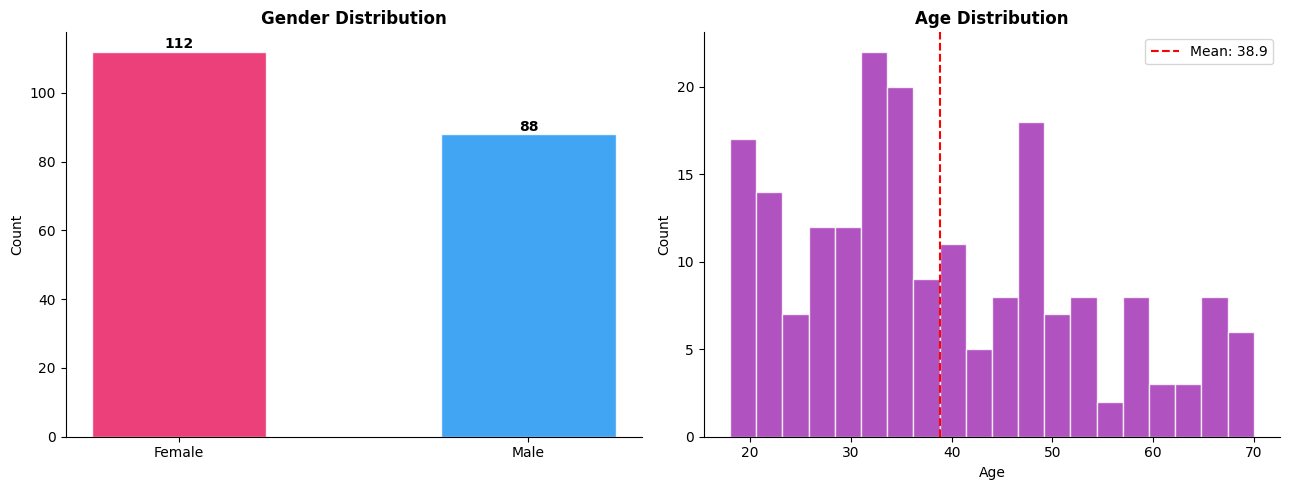

In [ ]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gender count
gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values,
            color=['#E91E63', '#2196F3'], alpha=0.85, edgecolor='white', width=0.5)
axes[0].set_title('Gender Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Age distribution
axes[1].hist(df['Age'], bins=20, color='#9C27B0', alpha=0.8, edgecolor='white')
axes[1].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[1].set_title('Age Distribution', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Income vs Spending Score scatter
fig = px.scatter(
    df, x='Annual Income (k$)', y='Spending Score (1-100)',
    color='Gender', symbol='Gender',
    hover_data=['CustomerID', 'Age'],
    title='Annual Income vs Spending Score (coloured by Gender)',
    color_discrete_map={'Male': '#2196F3', 'Female': '#E91E63'},
    template='plotly_white', width=800, height=500
)
fig.update_traces(marker=dict(size=8, opacity=0.75))
fig.show()

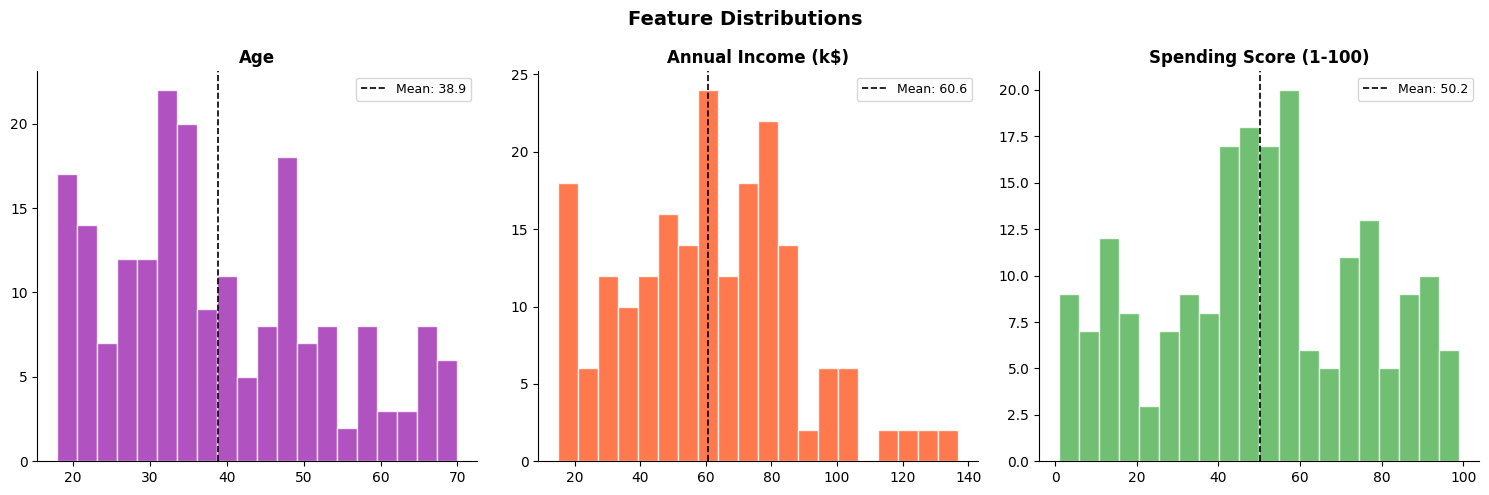

In [ ]:
# Pairplot of numeric features
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

colors = ['#9C27B0', '#FF5722', '#4CAF50']
for ax, col, color in zip(axes, numeric_cols, colors):
    ax.hist(df[col], bins=20, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

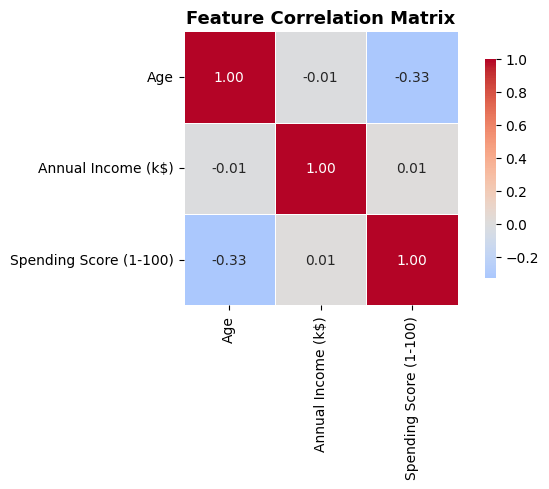

In [ ]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Encode Gender: Female=0, Male=1
df['Gender_encoded'] = LabelEncoder().fit_transform(df['Gender'])

# Features for clustering
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
# Note: Gender is encoded but we use the 3 core numeric features for primary clustering.
# You can add 'Gender_encoded' to features if you want gender in the clustering too.

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Features scaled: {features}')
print(f'Shape of scaled feature matrix: {X_scaled.shape}')

# Check scaled stats
pd.DataFrame(X_scaled, columns=features).describe().round(3)

✅ Features scaled: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Shape of scaled feature matrix: (200, 3)


,Age,Annual Income (k$),Spending Score (1-100)
count,200.000,200.000,200.000
mean,-0.000,-0.000,-0.000
std,1.003,1.003,1.003
min,-1.496,-1.739,-1.910
25%,-0.725,-0.728,-0.600
50%,-0.205,0.036,-0.008
75%,0.728,0.666,0.885
max,2.236,2.918,1.894


In [ ]:
# Elbow & Silhouette on 2-feature (Income + Spending Score) — the classic view
X2 = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
X2_scaled = StandardScaler().fit_transform(X2)

inertias_2d, sil_2d = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X2_scaled)
    inertias_2d.append(km.inertia_)
    sil_2d.append(silhouette_score(X2_scaled, km.labels_))

# Elbow & Silhouette on full 3-feature
inertias_3d, sil_3d = [], []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias_3d.append(km.inertia_)
    sil_3d.append(silhouette_score(X_scaled, km.labels_))

print('K  | Inertia(2D) | Sil(2D) | Inertia(3D) | Sil(3D)')
print('-' * 57)
for i, k in enumerate(K_range):
    print(f'{k:2d} | {inertias_2d[i]:11.1f} | {sil_2d[i]:.4f}  | {inertias_3d[i]:11.1f} | {sil_3d[i]:.4f}')

K  | Inertia(2D) | Sil(2D) | Inertia(3D) | Sil(3D)
---------------------------------------------------------
 2 |       269.7 | 0.3213  |       389.4 | 0.3355
 3 |       157.7 | 0.4666  |       295.2 | 0.3578
 4 |       108.9 | 0.4939  |       205.2 | 0.4040
 5 |        65.6 | 0.5547  |       168.2 | 0.4166
 6 |        55.1 | 0.5399  |       133.9 | 0.4284
 7 |        44.9 | 0.5281  |       117.0 | 0.4172
 8 |        37.2 | 0.4552  |       103.9 | 0.4082
 9 |        32.4 | 0.4571  |        93.1 | 0.4177
10 |        30.0 | 0.4432  |        82.4 | 0.4066


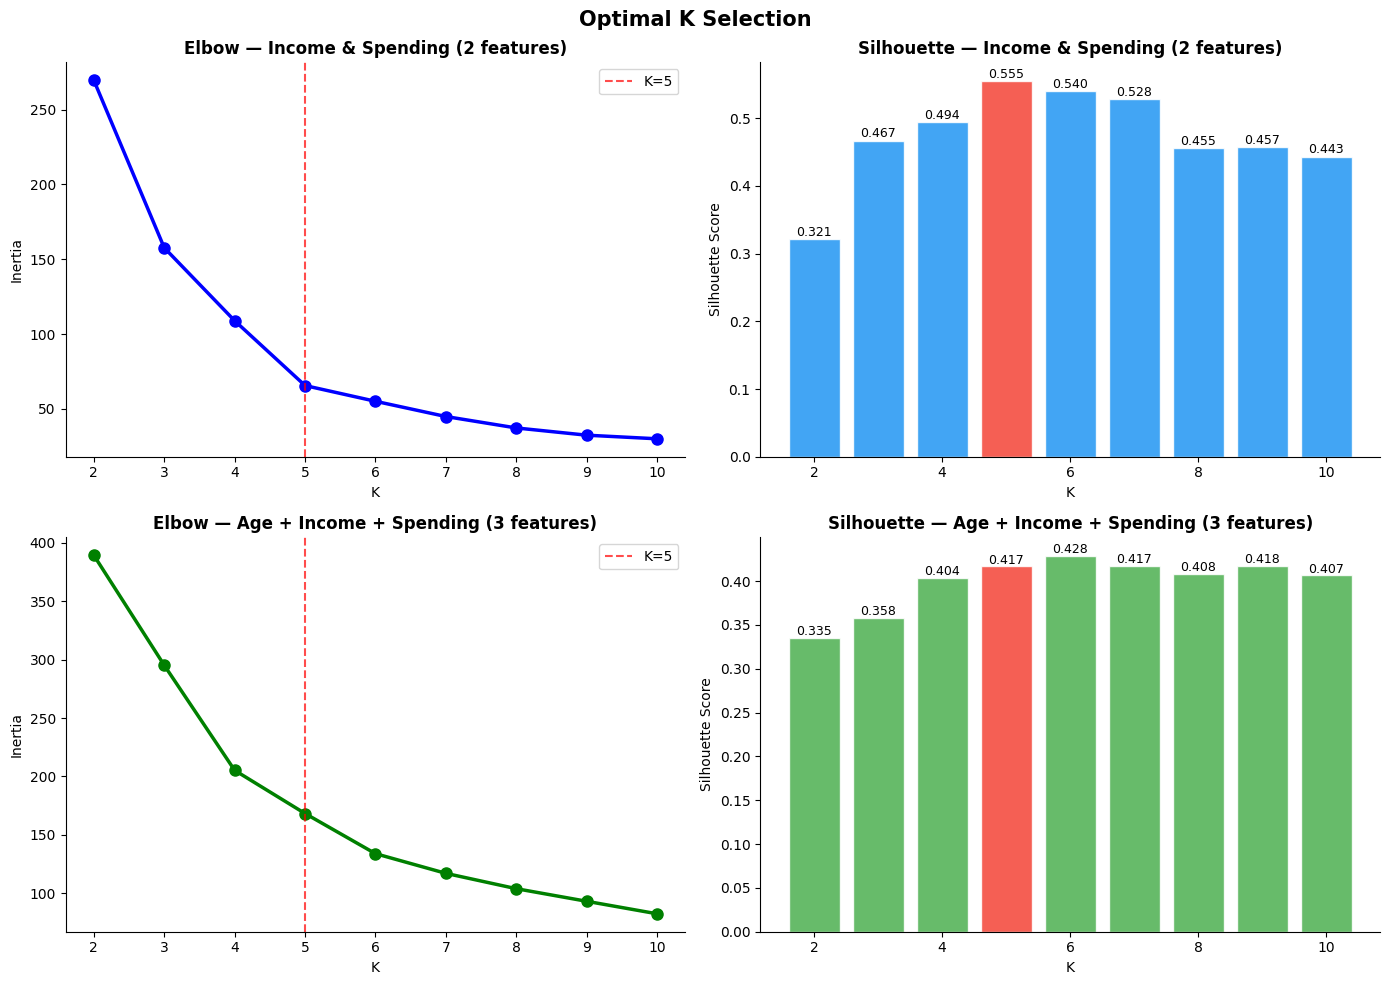


🎯 Optimal K = 5 (classic result for this dataset)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Optimal K Selection', fontsize=15, fontweight='bold')

# 2D Elbow
axes[0,0].plot(list(K_range), inertias_2d, 'bo-', linewidth=2.5, markersize=8)
axes[0,0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5')
axes[0,0].set_title('Elbow — Income & Spending (2 features)', fontweight='bold')
axes[0,0].set_xlabel('K'); axes[0,0].set_ylabel('Inertia')
axes[0,0].legend(); axes[0,0].spines['top'].set_visible(False); axes[0,0].spines['right'].set_visible(False)

# 2D Silhouette
bar_colors = ['#F44336' if k == 5 else '#2196F3' for k in K_range]
bars = axes[0,1].bar(list(K_range), sil_2d, color=bar_colors, alpha=0.85, edgecolor='white')
axes[0,1].set_title('Silhouette — Income & Spending (2 features)', fontweight='bold')
axes[0,1].set_xlabel('K'); axes[0,1].set_ylabel('Silhouette Score')
for bar, s in zip(bars, sil_2d):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{s:.3f}', ha='center', fontsize=9)
axes[0,1].spines['top'].set_visible(False); axes[0,1].spines['right'].set_visible(False)

# 3D Elbow
axes[1,0].plot(list(K_range), inertias_3d, 'go-', linewidth=2.5, markersize=8)
axes[1,0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5')
axes[1,0].set_title('Elbow — Age + Income + Spending (3 features)', fontweight='bold')
axes[1,0].set_xlabel('K'); axes[1,0].set_ylabel('Inertia')
axes[1,0].legend(); axes[1,0].spines['top'].set_visible(False); axes[1,0].spines['right'].set_visible(False)

# 3D Silhouette
bar_colors2 = ['#F44336' if k == 5 else '#4CAF50' for k in K_range]
bars2 = axes[1,1].bar(list(K_range), sil_3d, color=bar_colors2, alpha=0.85, edgecolor='white')
axes[1,1].set_title('Silhouette — Age + Income + Spending (3 features)', fontweight='bold')
axes[1,1].set_xlabel('K'); axes[1,1].set_ylabel('Silhouette Score')
for bar, s in zip(bars2, sil_3d):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{s:.3f}', ha='center', fontsize=9)
axes[1,1].spines['top'].set_visible(False); axes[1,1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('\n🎯 Optimal K = 5 (classic result for this dataset)')

In [ ]:
optimal_k = 5

# --- Primary model: Income + Spending Score (most interpretable) ---
scaler_2d = StandardScaler()
X2_scaled_final = scaler_2d.fit_transform(df[['Annual Income (k$)', 'Spending Score (1-100)']])

kmeans_2d = KMeans(n_clusters=optimal_k, init='k-means++', n_init=20,
                   max_iter=500, random_state=42)
kmeans_2d.fit(X2_scaled_final)
df['cluster_2d'] = kmeans_2d.labels_

# --- Secondary model: All 3 features ---
kmeans_3d = KMeans(n_clusters=optimal_k, init='k-means++', n_init=20,
                   max_iter=500, random_state=42)
kmeans_3d.fit(X_scaled)
df['cluster_3d'] = kmeans_3d.labels_

sil_2d_final = silhouette_score(X2_scaled_final, kmeans_2d.labels_)
sil_3d_final = silhouette_score(X_scaled, kmeans_3d.labels_)

print('✅ K-Means models trained!')
print(f'   2D model (Income + Spending) — Silhouette: {sil_2d_final:.4f}')
print(f'   3D model (Age + Income + Spending) — Silhouette: {sil_3d_final:.4f}')
print(f'\nCluster sizes (2D model):')
print(df['cluster_2d'].value_counts().sort_index())

✅ K-Means models trained!
   2D model (Income + Spending) — Silhouette: 0.5547
   3D model (Age + Income + Spending) — Silhouette: 0.4166

Cluster sizes (2D model):
cluster_2d
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [ ]:
# Cluster profiles (original scale)
profile_2d = df.groupby('cluster_2d')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean().round(1)
profile_2d['count'] = df.groupby('cluster_2d').size()
print('=== Cluster Centroids (2D model) ===')
print(profile_2d)

# Manually assign names after inspecting the centroid table above
# Typical mapping for Mall Customers K=5:
#  - Low income, low spending  → Cautious/Budget
#  - Low income, high spending → Impulsive Spenders
#  - Mid income, mid spending  → Standard Shoppers
#  - High income, low spending → Careful High-Earners
#  - High income, high spending → Target / Premium

# Auto-assign based on centroid position
centroids = df.groupby('cluster_2d')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

def assign_name(row):
    inc, sco = row['Annual Income (k$)'], row['Spending Score (1-100)']
    if inc < 50 and sco < 50:
        return 'Budget Cautious'
    elif inc < 50 and sco >= 50:
        return 'Impulsive Spenders'
    elif 45 <= inc <= 80 and 40 <= sco <= 60:
        return 'Standard Shoppers'
    elif inc >= 70 and sco < 50:
        return 'Careful High-Earners'
    else:
        return 'Premium Targets'

segment_map = centroids.apply(assign_name, axis=1).to_dict()
df['segment'] = df['cluster_2d'].map(segment_map)

print('\n=== Segment Assignment ===')
print(df['segment'].value_counts())

=== Cluster Centroids (2D model) ===
            Annual Income (k$)  Spending Score (1-100)   Age  count
cluster_2d                                                         
0                         55.3                    49.5  42.7     81
1                         86.5                    82.1  32.7     39
2                         25.7                    79.4  25.3     22
3                         88.2                    17.1  41.1     35
4                         26.3                    20.9  45.2     23

=== Segment Assignment ===
segment
Standard Shoppers       81
Premium Targets         39
Careful High-Earners    35
Budget Cautious         23
Impulsive Spenders      22
Name: count, dtype: int64


In [ ]:
# ── Classic 2D: Income vs Spending Score ──
fig = px.scatter(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    color='segment',
    symbol='Gender',
    hover_data=['CustomerID', 'Age', 'Gender'],
    title='Customer Segments — Annual Income vs Spending Score',
    color_discrete_sequence=px.colors.qualitative.Bold,
    template='plotly_white',
    width=850, height=580
)
fig.update_traces(marker=dict(size=9, opacity=0.82))
fig.update_layout(legend_title_text='Segment', title_font_size=16)
fig.show()

In [ ]:
# ── 3D: Age × Income × Spending Score ──
df['segment_3d'] = df['cluster_3d'].map(
    df.groupby('cluster_3d')['segment'].agg(lambda x: x.mode()[0])  # carry nearest 2D name
)

fig3d = px.scatter_3d(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    z='Age',
    color='segment',
    hover_data=['CustomerID', 'Gender'],
    title='3D Customer Segments — Income × Spending × Age',
    color_discrete_sequence=px.colors.qualitative.Bold,
    template='plotly_white',
    width=850, height=620
)
fig3d.update_traces(marker=dict(size=5, opacity=0.75))
fig3d.update_layout(legend_title_text='Segment', title_font_size=16)
fig3d.show()

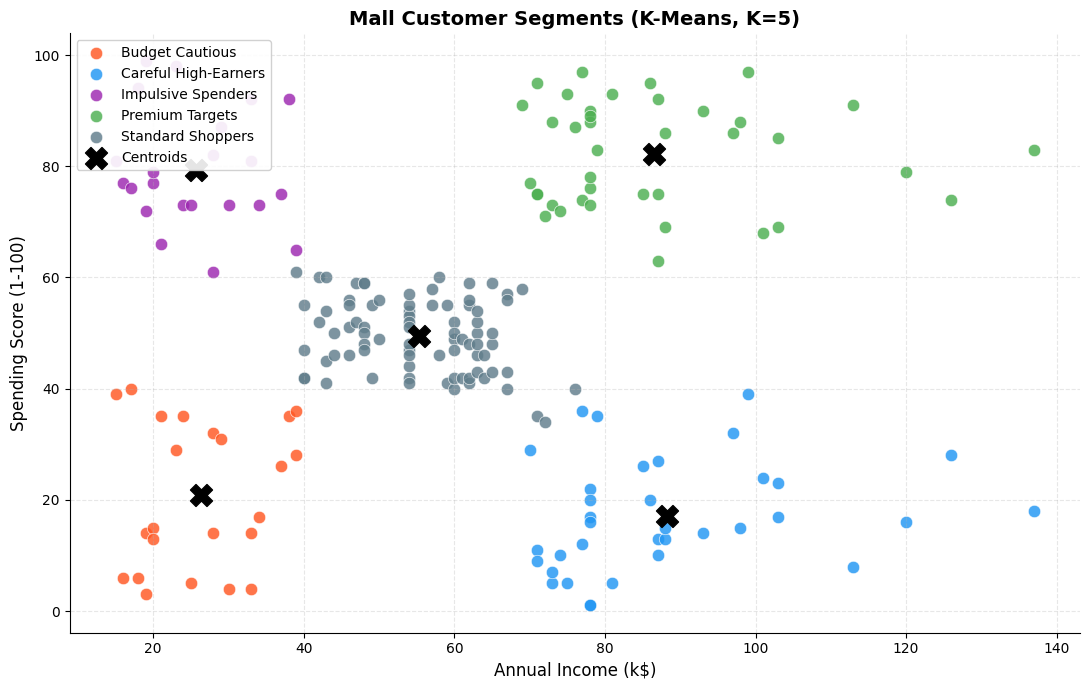

📊 Plot saved as customer_clusters.png


In [ ]:
# ── Matplotlib version (publication-quality static plot) ──
palette = {
    'Budget Cautious': '#FF5722',
    'Impulsive Spenders': '#9C27B0',
    'Standard Shoppers': '#607D8B',
    'Careful High-Earners': '#2196F3',
    'Premium Targets': '#4CAF50'
}

fig, ax = plt.subplots(figsize=(11, 7))

for seg, grp in df.groupby('segment'):
    ax.scatter(grp['Annual Income (k$)'], grp['Spending Score (1-100)'],
               label=seg, color=palette.get(seg, 'gray'),
               s=80, alpha=0.82, edgecolors='white', linewidths=0.5)

# Plot cluster centres
centres_orig = scaler_2d.inverse_transform(kmeans_2d.cluster_centers_)
ax.scatter(centres_orig[:, 0], centres_orig[:, 1],
           s=250, c='black', marker='X', zorder=5, label='Centroids')

ax.set_title('Mall Customer Segments (K-Means, K=5)', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1-100)', fontsize=12)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('customer_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Plot saved as customer_clusters.png')

In [ ]:
# Detailed profile table
profile = df.groupby('segment').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean'),
    Pct_Female=('Gender', lambda x: (x == 'Female').mean() * 100)
).round(1)
profile['Pct_of_Total'] = (profile['Count'] / len(df) * 100).round(1)
print('=== Detailed Cluster Profiles ===')
profile

=== Detailed Cluster Profiles ===


,Count,Avg_Age,Avg_Income,Avg_Spending,Pct_Female,Pct_of_Total
segment,,,,,,
Budget Cautious,23,45.2,26.3,20.9,60.9,11.5
Careful High-Earners,35,41.1,88.2,17.1,45.7,17.5
Impulsive Spenders,22,25.3,25.7,79.4,59.1,11.0
Premium Targets,39,32.7,86.5,82.1,53.8,19.5
Standard Shoppers,81,42.7,55.3,49.5,59.3,40.5


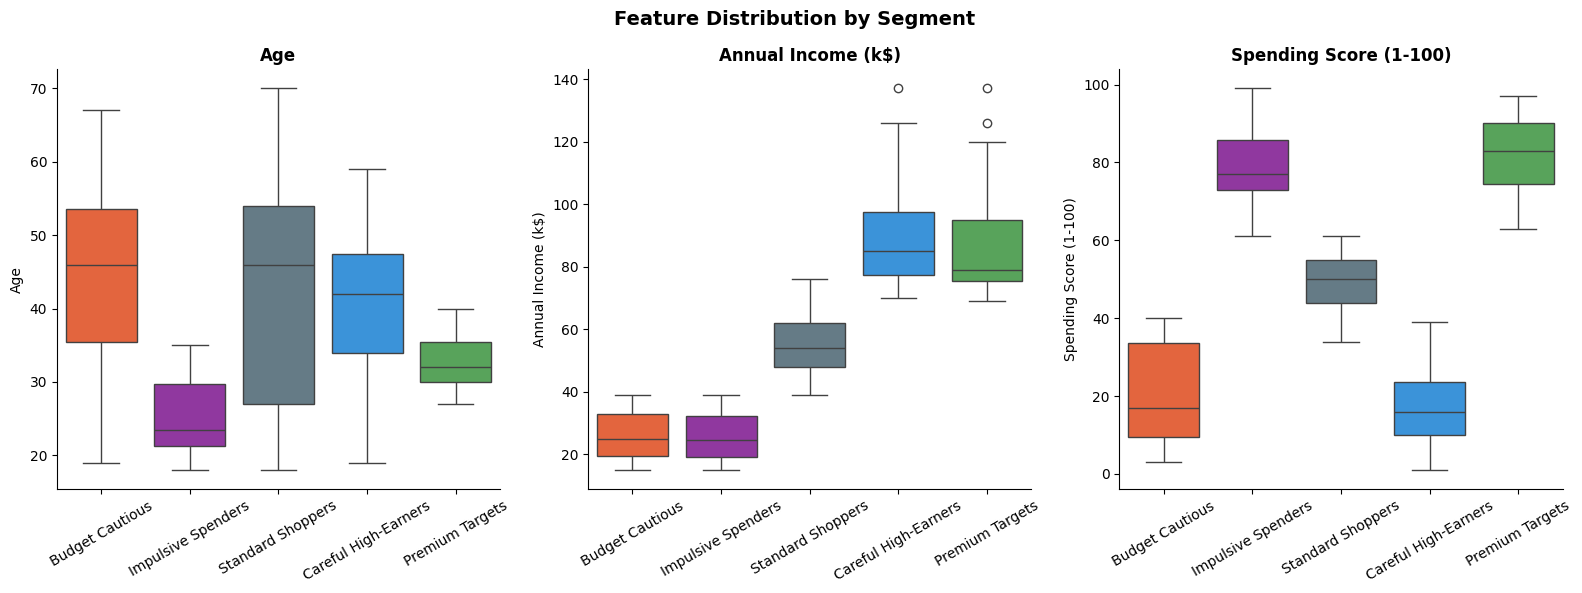

In [ ]:
# Box plots
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Feature Distribution by Segment', fontsize=14, fontweight='bold')

order = ['Budget Cautious', 'Impulsive Spenders', 'Standard Shoppers',
         'Careful High-Earners', 'Premium Targets']

for ax, col in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.boxplot(data=df, x='segment', y=col, order=order,
                palette=list(palette.values()), ax=ax)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

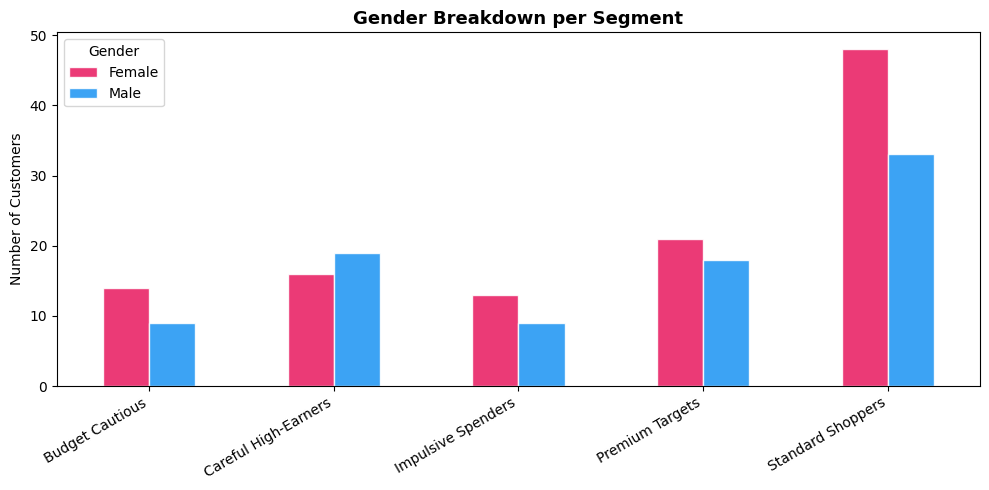

In [ ]:
# Gender breakdown per segment (stacked bar)
gender_seg = df.groupby(['segment', 'Gender']).size().unstack(fill_value=0)
gender_seg.plot(kind='bar', figsize=(10, 5), color=['#E91E63', '#2196F3'],
                edgecolor='white', alpha=0.88)
plt.title('Gender Breakdown per Segment', fontweight='bold', fontsize=13)
plt.xlabel('')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [ ]:
def predict_segment(annual_income, spending_score):
    """
    Predicts the segment for a new customer based on
    Annual Income (k$) and Spending Score (1-100).
    """
    new_cust = np.array([[annual_income, spending_score]])
    scaled = scaler_2d.transform(new_cust)
    cluster_id = kmeans_2d.predict(scaled)[0]
    segment = segment_map[cluster_id]
    return cluster_id, segment


# Example predictions
test_cases = [
    (120, 82, 'Expected: Premium Target'),
    (110, 15, 'Expected: Careful High-Earner'),
    (55,  50, 'Expected: Standard Shopper'),
    (20,  78, 'Expected: Impulsive Spender'),
    (18,  20, 'Expected: Budget Cautious'),
]

print(f'{"Income":>8}  {"Score":>6}  {"Cluster":>4}  {"Segment":>25}  Note')
print('-' * 80)
for inc, sco, note in test_cases:
    cid, seg = predict_segment(inc, sco)
    print(f'  ${inc:>5}k     {sco:>3}      {cid}    {seg:>25}  # {note}')

  Income   Score  Cluster                    Segment  Note
--------------------------------------------------------------------------------
  $  120k      82      1              Premium Targets  # Expected: Premium Target
  $  110k      15      3         Careful High-Earners  # Expected: Careful High-Earner
  $   55k      50      0            Standard Shoppers  # Expected: Standard Shopper
  $   20k      78      2           Impulsive Spenders  # Expected: Impulsive Spender
  $   18k      20      4              Budget Cautious  # Expected: Budget Cautious


In [ ]:
# Save the full segmented dataframe
output_cols = ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
               'Spending Score (1-100)', 'cluster_2d', 'segment']
df[output_cols].to_csv('mall_customers_segmented.csv', index=False)

# Download in Colab
from google.colab import files
files.download('mall_customers_segmented.csv')
files.download('customer_clusters.png')

print('✅ Files downloaded:')
print('   - mall_customers_segmented.csv')
print('   - customer_clusters.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded:
   - mall_customers_segmented.csv
   - customer_clusters.png
